# Polynomial Regression — Energy Demand (Realistic Generator)

Nonlinear regression: polynomial features, regularization, CV, and bias/variance diagnostics.

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Generate a realistic energy dataset

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(SEED)
n = 6000
temp_c = rng.normal(15, 10, n)
humidity = np.clip(rng.normal(0.55, 0.15, n), 0.1, 0.95)
hour = rng.integers(0, 24, n)
is_weekend = rng.integers(0, 2, n)

# Nonlinear demand curve (U-shape vs temperature + daily cycle)
daily_cycle = 1.0 + 0.35*np.sin(2*np.pi*hour/24) + 0.15*np.cos(2*np.pi*hour/24)
temp_effect = 1.0 + 0.018*(temp_c - 18)**2
weekend_effect = np.where(is_weekend==1, 0.92, 1.0)
noise = rng.normal(0, 0.12, n)
demand = 120 * daily_cycle * temp_effect * weekend_effect * (1 + 0.25*(humidity-0.55)) * (1+noise)

df = pd.DataFrame({
    'temp_c': temp_c,
    'humidity': humidity,
    'hour': hour,
    'is_weekend': is_weekend,
    'demand': demand
})

display(df.head())
df.describe().T


,temp_c,humidity,hour,is_weekend,demand
0,18.047171,0.583768,13,0,92.925830
1,4.600159,0.541999,6,1,591.077445
2,22.504512,0.679607,14,0,140.179439
3,24.405647,0.641010,15,0,111.925565
4,-4.510352,0.102127,3,1,1155.879672


,count,mean,std,min,25%,50%,75%,max
temp_c,6000.0,14.916262,10.031126,-28.891146,8.188992,15.083938,21.408365,49.540464
humidity,6000.0,0.547556,0.150248,0.100000,0.448458,0.543663,0.649123,0.950000
hour,6000.0,11.621500,6.917650,0.000000,6.000000,12.000000,18.000000,23.000000
is_weekend,6000.0,0.505500,0.500011,0.000000,0.000000,1.000000,1.000000,1.000000
demand,6000.0,343.639443,354.859585,48.678155,137.488376,213.401898,408.543871,3585.115180


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

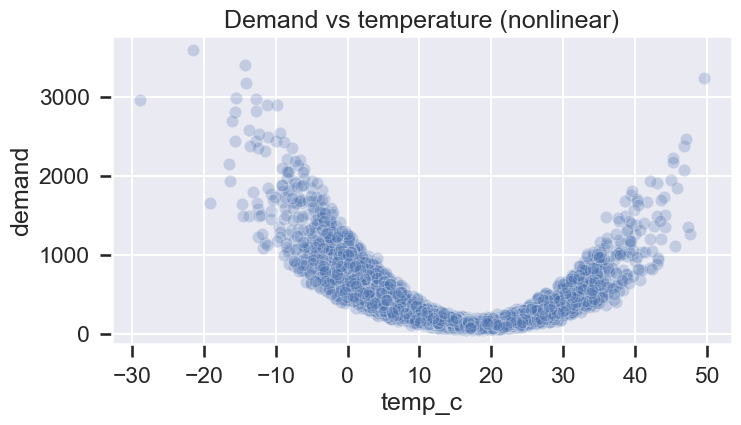

In [3]:
plt.figure(figsize=(8,4))
sns.scatterplot(x='temp_c', y='demand', data=df, alpha=0.25)
plt.title('Demand vs temperature (nonlinear)')
plt.show()


## Baseline vs polynomial models (CV)

Polynomial features can explode variance—regularization + CV are essential.

In [4]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer

X = df.drop(columns=['demand'])
y = df['demand']

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

pipe_lin = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', LinearRegression())])
pipe_poly_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', Ridge(random_state=SEED))
])

res_lin = cross_validate(pipe_lin, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print('Linear RMSE:', -res_lin['test_rmse'].mean(), 'R2:', res_lin['test_r2'].mean())

grid = {
    'poly__degree': [1, 2, 3, 4],
    'model__alpha': np.logspace(-3, 3, 13),
}
gs = GridSearchCV(pipe_poly_ridge, grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(X, y)
print('Best poly+ridge RMSE:', -gs.best_score_)
print('Best params:', gs.best_params_)


Linear RMSE: 322.9902805903252 R2: 0.16821633396897512
Best poly+ridge RMSE: 74.54520281821459
Best params: {'model__alpha': np.float64(0.01), 'poly__degree': 4}
